### Importação de bibliotecas

In [57]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import geopandas as gpd
import unicodedata # Para normalizar nomes de estados
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.patheffects as PathEffects # Para contorno nos labels
import os # Para usar o figpath
from scipy.stats import pearsonr
import numpy as np


### Funções úteis

In [58]:
def fmt_abrev(v, casas_M=2):
    '''
    Função utilizada para "diminuir" labels, transformando, por exemplo:
    1000000 em 1M,
    3000 em 3k
    Aplica-se em um número.
    casas_M controla as casas decimais nos milhões (2 -> 1.25M / 0 -> 1M)
    '''
    if v >= 1e6: return f'{v/1e6:.{casas_M}f}M'
    if v >= 1e3: return f'{v/1e3:.0f}k'
    if v >= 1:   return f'{v:.0f}'
    if v > 0:    return f'{v:g}'          # casas decimais p/ valores < 1 (Pb)
    return '0'

### Dicionários úteis

In [59]:
estado_sigla = {
    'ACRE': 'AC', 'ALAGOAS': 'AL', 'AMAPA': 'AP', 'AMAZONAS': 'AM',
    'BAHIA': 'BA', 'CEARA': 'CE', 'DISTRITO FEDERAL': 'DF', 'ESPIRITO SANTO': 'ES',
    'GOIAS': 'GO', 'MARANHAO': 'MA', 'MATO GROSSO': 'MT', 'MATO GROSSO DO SUL': 'MS',
    'MINAS GERAIS': 'MG', 'PARA': 'PA', 'PARAIBA': 'PB', 'PARANA': 'PR',
    'PERNAMBUCO': 'PE', 'PIAUI': 'PI', 'RIO DE JANEIRO': 'RJ', 'RIO GRANDE DO NORTE': 'RN',
    'RIO GRANDE DO SUL': 'RS', 'RONDONIA': 'RO', 'RORAIMA': 'RR', 'SANTA CATARINA': 'SC',
    'SAO PAULO': 'SP', 'SERGIPE': 'SE', 'TOCANTINS': 'TO'
}

mapa_uf_siglaregiao = {
    'AC': 'N', 'AP': 'N', 'AM': 'N', 'PA': 'N', 'RO': 'N', 'RR': 'N',
    'TO': 'N','AL': 'NE', 'BA': 'NE', 'CE': 'NE', 'MA': 'NE',
    'PB': 'NE', 'PE': 'NE', 'PI': 'NE', 'RN': 'NE', 'SE': 'NE',
    'DF': 'MW', 'GO': 'MW', 'MT': 'MW', 'MS': 'MW',
    'ES': 'SE', 'MG': 'SE', 'RJ': 'SE', 'SP': 'SE',
    'PR': 'S', 'RS': 'S', 'SC': 'S'
}

REGIAO_TO_SIGLA = {
    'Norte': 'N', 'N': 'N',
    'Nordeste': 'NE', 'NE': 'NE',
    'Centro-oeste': 'MW', 'Centro-Oeste': 'MW', 'CO': 'MW', 'MW': 'MW',
    'Sudeste': 'SE', 'SE': 'SE',
    'Sul': 'S', 'S': 'S',
}

### Definição de caminhos e inputs

In [60]:
repo_path = '/home/gabriellimasclg/Documents/Códigos_GitHub/Mestrado_GitHub/008.2026 - Artigo CMAS'
figpath = os.path.join(repo_path,'figures')

#importar csv com inventário
df = pd.read_csv(os.path.join(repo_path,'inputs','inventarioEmissoesIndustriaisIndustriaAlimenticiaBR_V3.csv'), encoding='utf-8')

#importa shape do br
br_regiao = gpd.read_file('/home/gabriellimasclg/Documents/Códigos_GitHub/shape_base/BR_Regioes_2025/BR_Regioes_2025.shp')

In [61]:
df['SIGLA_UF'] = df['ESTADO'].map(estado_sigla)
df['SIGLA_RG_en'] = df['SIGLA_UF'].map(mapa_uf_siglaregiao)
br_regiao['SIGLA_RG_en'] = br_regiao['NM_REGIAO'].map(REGIAO_TO_SIGLA)

### série histórica anual

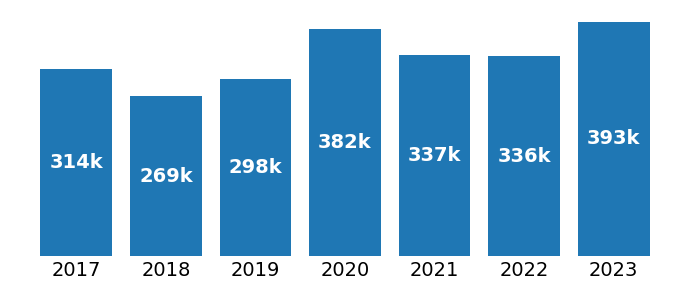

In [62]:
def annual_series(df,year_column,emissions_column,figpath):

    def fmt_abrev(v, casas_M=2):
        '''
        Função utilizada para "diminuir" labels, transformando, por exemplo:
        1000000 em 1M,
        3000 em 3k
        Aplica-se em um número.
        casas_M controla as casas decimais nos milhões (2 -> 1.25M / 0 -> 1M)
        '''
        if v >= 1e6: return f'{v/1e6:.{casas_M}f}M'
        if v >= 1e3: return f'{v/1e3:.0f}k'
        if v >= 1:   return f'{v:.0f}'
        if v > 0:    return f'{v:g}'          # casas decimais p/ valores < 1 (Pb)
        return '0'

    df_year = df[[year_column,
        emissions_column]].groupby(by=year_column).sum()

    df_year

    fig, ax = plt.subplots(figsize=(7, 3),tight_layout=True)

    bars = ax.bar(df_year.index, df_year[emissions_column])
    ax.bar_label(bars,
                labels=df_year[emissions_column].apply(fmt_abrev),
                fontsize=14,
                label_type='center',
                color = 'white',
                fontweight = 'bold')

    ax.set_frame_on(False)
    ax.tick_params(axis='x', labelsize=14)

    # retirando o eixo y
    ax.set_yticks([])
    ax.tick_params(axis='x', length=0)

    plt.savefig(os.path.join(figpath,'serie_emissoes.png'),dpi=300)

    plt.show()

annual_series(df=df,
              year_column = 'num_ano',
              emissions_column = 'Emissão NMCOV (ton)',
              figpath=figpath)

### mapa de pixel por UF + inset de emissões por regiao


In [63]:
df.columns

Index(['CNPJ', 'MUNICIPIO', 'LATITUDE', 'LONGITUDE', 'ESTADO',
       'SITUACAO CADASTRAL', 'CODIGO DA CATEGORIA', 'CODIGO DA ATIVIDADE',
       'ANO_INICIO', 'ANO_FIM', 'mv.num_cpf_cnpj', 'mv.nom_pessoa',
       'mv.nom_municipio', 'num_ano', 'cod_produto', 'unidade_medida',
       'sig_unidmed', 'nom_produto', 'qtd_produzida', 'qtd_instalada',
       'informacao_sigilosa', 'tipo_sigilo', 'lei_sigilo', 'info_sigilo',
       '_merge', 'status_v01', 'PRODLIST', 'NFR', 'Table', 'Sector', 'Type',
       'Technology', 'Fuel', 'Abatement', 'Region', 'Pollutant', 'Value',
       'Unit', 'CI_lower', 'CI_upper', 'Reference', 'status_v02',
       'contagem_total_grupo', 'status_v03', 'sig_unidmed_novo',
       'qtd_convertida_prev', 'categoria', 'q90_setor_prev', 'status_q90_prev',
       'status_serie', 'status_correcaoManualUnidade', 'fatorConversao',
       'qtd_convertida', 'mediana_serie', 'razao_vs_mediana', 'q95_categoria',
       'status_v04', 'status_v05', 'fator_escala', 'Unnamed: 59'

In [69]:
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from matplotlib.colorbar import ColorbarBase
import numpy as np

def plot_mapa_pixels_emissao(df, br_regiao,figpath):
    """
    Mapa de pixels (grade ~20x20km) de emissão de NMCOV, colorido por
    escala log (inferno_r), com rótulos de região semi-transparentes,
    contorno das regiões e inset de barras somando a emissão por região.
    """

    # ---------- 1. filtra ano ----------
    sub = df.copy()
    sub = sub[sub['num_ano'] == 2023]
    sub = sub.dropna(subset=['LATITUDE', 'LONGITUDE', 'Emissão NMCOV (ton)'])

    if sub.empty:
        print('Sem dados para 2023.')
        return

    # ---------- 2. cria GeoDataFrame de pontos ----------
    gdf_pts = gpd.GeoDataFrame(
        sub,
        geometry=gpd.points_from_xy(sub['LONGITUDE'], sub['LATITUDE']),
        crs=br_regiao.crs,
    )

    # ---------- 3. grid 20x20km ----------
    continental = br_regiao.cx[:-34, :]
    minx, miny, maxx, maxy = continental.total_bounds

    x_coords = np.arange(minx, maxx, 0.18)
    y_coords = np.arange(miny, maxy, 0.18)
    cells = [box(x, y, x + 0.18, y + 0.18)
             for x in x_coords for y in y_coords]
    grid = gpd.GeoDataFrame(geometry=cells, crs=br_regiao.crs)
    grid['grid_id'] = grid.index

    pontos_na_grade = gpd.sjoin(
        gdf_pts, grid[['geometry', 'grid_id']],
        how='inner', predicate='within'
    )

    # ---------- 4. agrega emissão por célula (soma) ----------
    emis_por_grid = (
        pontos_na_grade.groupby('grid_id')['Emissão NMCOV (ton)'].sum().reset_index()
    )
    grid_plot = grid.merge(emis_por_grid, on='grid_id', how='inner')
    grid_plot = grid_plot[grid_plot['Emissão NMCOV (ton)'] > 0]

    # ---------- 5. escala de cor (log) ----------
    cmap = plt.get_cmap('inferno_r').copy()
    cmap.set_bad(color='none')

    valores = grid_plot['Emissão NMCOV (ton)'].values
    vmin = max(valores.min(), 1e-3)
    vmax = valores.max()
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

    # ---------- 6. plot ----------
    fig, ax = plt.subplots(figsize=(9, 9), dpi=200, facecolor='white')

    br_regiao.plot(ax=ax, color='#f2f2f2', edgecolor='#888888',
                    linewidth=0.4, zorder=1)

    grid_plot.plot(ax=ax, column='Emissão NMCOV (ton)', cmap=cmap, norm=norm,
                    edgecolor='none', linewidth=0, zorder=2)

    br_regiao.boundary.plot(ax=ax, color='#444444', linewidth=0.6, zorder=3)

    # rótulos das regiões, com opacidade, nos centroides
    if 'SIGLA_RG_en' in br_regiao.columns:
        for _, row in br_regiao.iterrows():
            if row.geometry is None or row.geometry.is_empty:
                continue
            c = row.geometry.centroid
            ax.text(c.x, c.y, str(row['SIGLA_RG_en']), ha='center', va='center',
                    fontsize=22, fontweight='bold', alpha=0.55,
                    color='#222222', zorder=5,
                    path_effects=[pe.withStroke(linewidth=3, foreground='white', alpha=0.6)])

    ax.set_xlim(minx - 0.5, maxx - 0.8)
    ax.set_ylim(miny - 0.5, maxy + 0.5)
    ax.set_axis_off()

    # ---------- 7. colorbar ----------
    ax_cb = ax.inset_axes([0.86, 0.05, 0.05, 0.5])
    cb = ColorbarBase(ax_cb, cmap=cmap, norm=norm, orientation='vertical')
    cb.set_label('NMCOV (t) [log]', fontsize=16, labelpad=4)
    cb.ax.tick_params(labelsize=16, length=3, pad=2)
    cb.outline.set_linewidth(0.5)

    # ---------- 8. inset de barras: soma da emissão por figpathregião ----------
    if 'SIGLA_RG_en' in sub.columns:
        emis_reg = (sub.groupby('SIGLA_RG_en')['Emissão NMCOV (ton)'].sum()
                       .reindex(['S', 'SE', 'MW', 'NE', 'N'], fill_value=0))

        ax_bar = ax.inset_axes([0.01, 0.15, 0.34, 0.3])
        x_pos = np.arange(5)
        bars = ax_bar.bar(x_pos, emis_reg.values, color='#2b6cb0',
                           alpha=0.95, edgecolor='white', linewidth=0.3)

        ax_bar.set_xticks(x_pos)
        ax_bar.set_xticklabels(['S', 'SE', 'MW', 'NE', 'N'], fontsize=16,
                                fontweight='bold', rotation=90)
        ax_bar.tick_params(axis='y', left=False, labelleft=False)
        ax_bar.tick_params(axis='x', length=0)
        ax_bar.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
        ax_bar.patch.set_alpha(0)

        ymax = emis_reg.values.max() if emis_reg.values.max() > 0 else 1
        ax_bar.set_ylim(0, ymax * 1.30)
        for bar, val in zip(bars, emis_reg.values):
            if val > 0:
                txt = (f'{val/1e6:.1f}M' if val >= 1e6 else
                       f'{val/1e3:.0f}k' if val >= 1e3 else
                       f'{val:.0f}')
                ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                            txt, ha='center', va='bottom',
                            fontsize=16, fontweight='bold',
                            color='#222222')

    plt.tight_layout()

    plt.savefig(os.path.join(figpath,'emissoes_pixel.png'),dpi=300)

    plt.show()
    return fig, ax

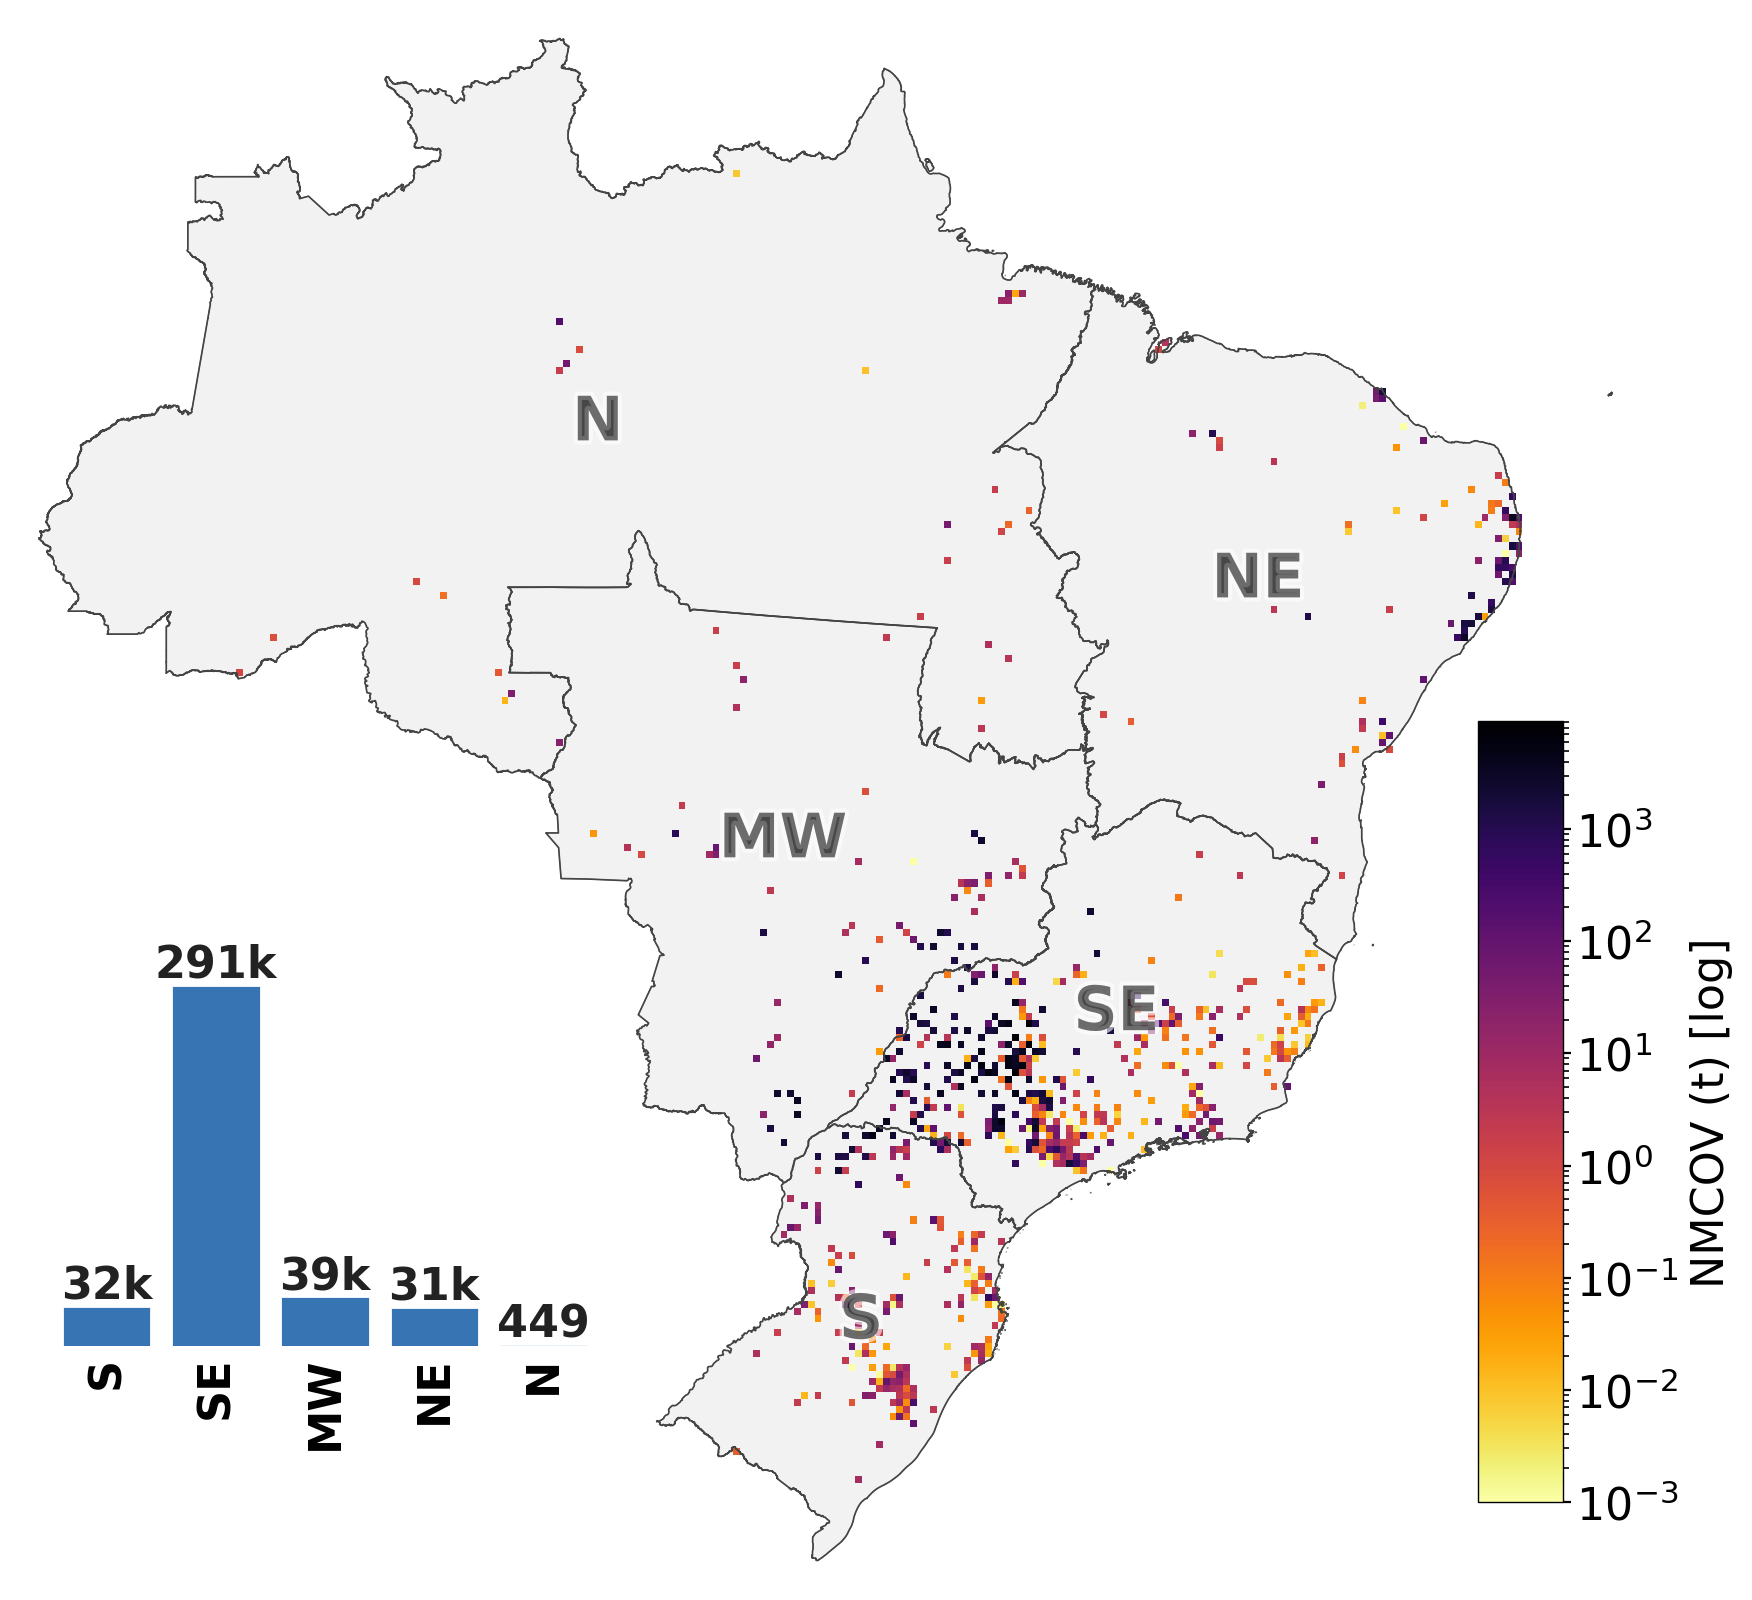

(<Figure size 1800x1800 with 1 Axes>, <Axes: >)

In [70]:
plot_mapa_pixels_emissao(
    df=df,
    br_regiao=br_regiao,
    figpath=figpath
)

### PIA açucar

In [71]:
# Filtra apenas açucar no inv com colunas úteis
df_sugar = df[df['Technology'] == 'Sugar'][['PRODLIST', 'num_ano', 'Technology', 'prodtonhl_v5']]
df_sugar = df_sugar.rename(columns={'prodtonhl_v5':'Inventory Production (t)','num_ano':'Year'})

#df anual
df_sugar_anual = df_sugar[['Year', 'Inventory Production (t)']].groupby(by='Year').sum()

# gera uma lista com os prodlist de açucar para filtrar no pia dps
prodlist_sugar = [str(n).ljust(9, '0') for n in df_sugar['PRODLIST'].unique()]

#Arquivo PIA
pia = pd.read_csv(os.path.join(repo_path,'inputs','PIA_Tratado.csv'),dtype={'cod_produto':'string'})

#filtra apenas os msm prodlist
pia_sugar = pia[pia['cod_produto'].isin(prodlist_sugar)]
pia_sugar = pia_sugar.rename(columns={'PRODUÇÃO_NOVO':'PIA Production (t)','ANO':'Year'})

#df anual
pia_sugar_anual = pia_sugar[['Year', 'PIA Production (t)']].groupby(by='Year').sum()


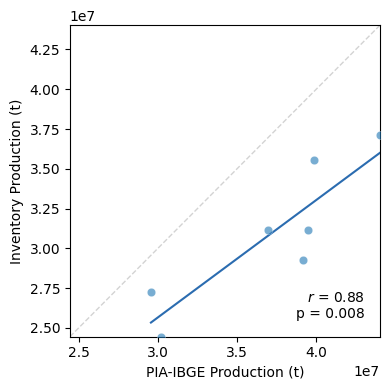

In [72]:
df_corr_sugar = pd.merge(left = pia_sugar_anual,right=df_sugar_anual,on='Year')

fig, ax = plt.subplots(figsize=(4, 4))

x = df_corr_sugar['PIA Production (t)']
y = df_corr_sugar['Inventory Production (t)']

ax.scatter(x, y, alpha=0.6, edgecolor='white', linewidth=0.3, zorder=3)

# calcula correlação de Pearson
corr, p_value = pearsonr(x, y)

# --- linha de ajuste (regressão linear) ---
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_sorted = np.sort(x)
ax.plot(x_sorted, p(x_sorted), color='#2b6cb0', linewidth=1.5, zorder=2)

# --- diaEDGAR gonal y = x (referência), cinza claro ---
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
ax.plot(lims, lims, color='lightgray', linewidth=1, linestyle='--', zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel('PIA-IBGE Production (t)')
ax.set_ylabel('Inventory Production (t)')

# --- anotação r² e p, canto inferior direito, 2 linhas ---
ax.text(0.95, 0.05, f'$r$ = {corr:.2f}\np = {p_value:.3f}',
        transform=ax.transAxes, fontsize=10,
        ha='right', va='bottom')

plt.tight_layout()

plt.savefig(os.path.join(figpath,'corr_PIA_sugar.png'),dpi=300)

plt.show()

### Edgar spearman

In [73]:
edgar_dict = {
'2017': 9014.98,
'2018': 9621.9,
'2019': 10279.21,
'2020': 8912.8,
'2021': 8374.95,
'2022': 8363.45
}

In [76]:
from scipy.stats import spearmanr

# --- transforma o dict do EDGAR em DataFrame ---c.png'),dpi=30
edgar_df = pd.DataFrame(
    list(edgar_dict.items()), columns=['Year', 'EDGAR Emission (t)']
)
edgar_df['Year'] = edgar_df['Year'].astype(int)  # garante mesmo tipo que 'Year' do inventário

# --- garante que Year seja coluna nos outros dois (corrige o bug do groupby) ---
pia_sugar_anual = pia_sugar_anual.reset_index()
df_sugar_anual = df_sugar_anual.reset_index()

# --- mescla inventário com EDGAR ---
df_corr_edgar = pd.merge(left=df_sugar_anual, right=edgar_df, on='Year')

# --- Spearman ---
x = df_corr_edgar['EDGAR Emission (t)']
y = df_corr_edgar['Inventory Production (t)']

rho, p_value = spearmanr(x, y)
print(f'Spearman rho = {rho:.2f}, p = {p_value:.3f}')

Spearman rho = -0.71, p = 0.111


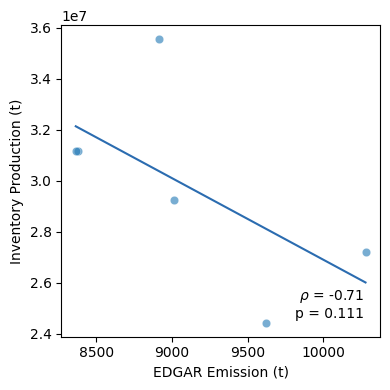

In [78]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(x, y, alpha=0.6, edgecolor='white', linewidth=0.3, zorder=3)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_sorted = np.sort(x)
ax.plot(x_sorted, p(x_sorted), color='#2b6cb0', linewidth=1.5, zorder=2)

ax.set_xlabel('EDGAR Emission (t)')
ax.set_ylabel('Inventory Production (t)')

ax.text(0.95, 0.05, f'$\\rho$ = {rho:.2f}\np = {p_value:.3f}',
        transform=ax.transAxes, fontsize=10,
        ha='right', va='bottom')

plt.tight_layout()

plt.savefig(os.path.join(figpath,'corr_EDGAR.png'),dpi=300)

plt.show()